In [1]:
#FashionMNIST
#不变动位置

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler
import numpy as np

california_housing = fetch_california_housing(data_home='./data')
X, y = california_housing.data, california_housing.target

from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_val_scaled = scaler_X.transform(X_val)
X_test_scaled = scaler_X.transform(X_test)

class CaliforniaHousingDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.FloatTensor(y)
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx].unsqueeze(0)

train_dataset = CaliforniaHousingDataset(X_train_scaled, y_train)
val_dataset = CaliforniaHousingDataset(X_val_scaled, y_val)
test_dataset = CaliforniaHousingDataset(X_test_scaled, y_test)

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

for x,y in train_loader:
    print(x.shape)
    print(y.shape)
    break

torch.Size([64, 8])
torch.Size([64, 1])


In [ ]:
#WideDeep模型搭建
class WideDeep(nn.Module):
    def __init__(self, input_dim=8):
        super().__init__()
        self.deep = nn.Sequential(
            nn.Linear(input_dim, 30),
            nn.ReLU(),
            nn.Linear(30, 30),
        )
        
        self.out = nn.Linear(30 + input_dim, 1)
    
        self.init_weights()
    
    def init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)
    
    def forward(self, x):
        deep_out = self.deep(x)
        concat = torch.cat([deep_out, x], dim=1)
        return self.out(concat)



device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

model = WideDeep(input_dim=8)
model.to(device)

x_sample = torch.randn(4, 8, device=device)  # 假设batch size为4, 特征数为8
output = model(x_sample)

print(x_sample.shape)
print(output.shape)
print(output)


cuda
torch.Size([4, 8])
torch.Size([4, 1])
tensor([[1.1152],
        [1.1161],
        [0.6774],
        [1.2788]], device='cuda:0', grad_fn=<AddmmBackward0>)


In [3]:
import my_trainer as mt

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

early_stopping = mt.EarlyStopping(patience=10, min_delta=0.001,mode='min')

model_checkpoint = mt.ModelCheckpoint(
    filepath='./checkpoints/regression_model_epoch_{epoch}.ckpt',
    monitor='val_loss',
    mode='min',
    save_best_only=True,
    min_delta=0.001
)

trainer = mt.Trainer(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    eval_step=50,
    early_stopping=early_stopping,
    model_checkpoint=model_checkpoint
)

trainer.train_regression(num_epochs=100)

[Step 50] Val Loss: 1.3863
[Step 100] Val Loss: 0.9525
[Step 150] Val Loss: 0.8309
[Step 200] Val Loss: 0.7568
Epoch [1/100]  Train Loss: 1.3489
[Step 250] Val Loss: 0.6909
[Step 300] Val Loss: 0.6323
[Step 350] Val Loss: 0.5883
[Step 400] Val Loss: 0.5412
[Step 450] Val Loss: 0.5046
Epoch [2/100]  Train Loss: 0.5943
[Step 500] Val Loss: 0.4796
[Step 550] Val Loss: 0.4658
[Step 600] Val Loss: 0.4533
[Step 650] Val Loss: 0.4433
Epoch [3/100]  Train Loss: 0.4553
[Step 700] Val Loss: 0.4362
[Step 750] Val Loss: 0.4360
[Step 800] Val Loss: 0.4228
[Step 850] Val Loss: 0.4296
[Step 900] Val Loss: 0.4168
Epoch [4/100]  Train Loss: 0.4161
[Step 950] Val Loss: 0.4125
[Step 1000] Val Loss: 0.4138
[Step 1050] Val Loss: 0.4097
[Step 1100] Val Loss: 0.4040
Epoch [5/100]  Train Loss: 0.3989
[Step 1150] Val Loss: 0.4003
[Step 1200] Val Loss: 0.3994
[Step 1250] Val Loss: 0.3964
[Step 1300] Val Loss: 0.3935
[Step 1350] Val Loss: 0.3919
Epoch [6/100]  Train Loss: 0.3824
[Step 1400] Val Loss: 0.3964
[Ste

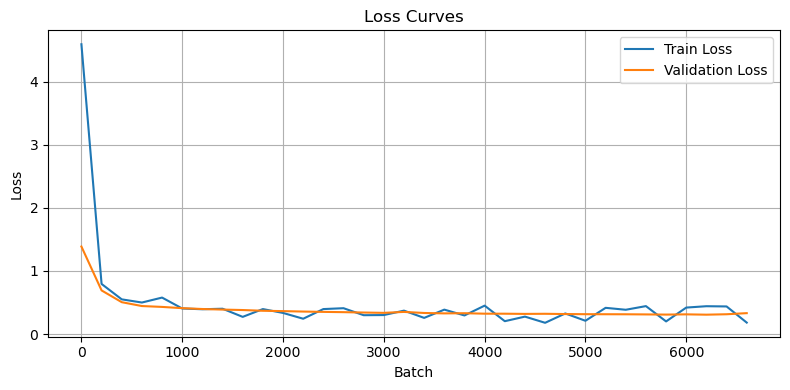

In [4]:
trainer.plot_curves(200)